# Chương 2: Phân tích tăng trưởng khu vực và phát hiện bất thường doanh thu

Pipeline:

1. Kiểm tra cấu trúc dữ liệu và phạm vi phân tích.
2. Tải dữ liệu bán hàng B2C theo đúng grain `Tháng × Khu vực`.
3. Kiểm tra mức độ đầy đủ của từng tháng và loại tháng chưa hoàn chỉnh.
4. Tính KPI khu vực, tăng trưởng, khách hàng mới và retention thực tế.
5. Phân tích quy mô – tăng trưởng.
6. **Data Mining - Phân cụm khu vực bằng K-Means**:
7. Phát hiện tăng/giảm doanh thu bất thường bằng STL.
8. So sánh actual với forecast theo bản dự báo mới nhất.
9. Sinh kết luận và gợi ý hành động.
10. Ghi kết quả vào các bảng riêng trong schema `ml`.

### Câu hỏi kinh doanh cốt lõi:
1. **Khu vực nào đang tăng trưởng và nên đầu tư thêm?**
2. **Khu vực nào doanh thu thấp nhưng còn dư địa?**
3. **Khu vực nào có doanh thu cao nhưng khách hàng quay lại đang giảm?**
4. **Khu vực nào suy giảm bất thường so với lịch sử và dự báo?**

> **Phạm vi:** Chương này sử dụng `dwh.fact_internet_sales` để phân tích doanh thu, đơn hàng và chỉ số khách hàng cùng thuộc kênh B2C. Phân tích B2B Reseller sẽ được thực hiện riêng.


## 1. Cấu hình và kết nối PostgreSQL DWH

In [18]:
import sys
import os
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from statsmodels.tsa.seasonal import STL
from sqlalchemy import text

# Cho phép import module trong thư mục src
sys.path.append(os.path.abspath(os.path.join("..")))
from src.common.database import get_dwh_engine

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams["figure.figsize"] = (12, 6)

# Tham số có thể điều chỉnh
COMPLETE_MONTH_MIN_RATIO = 1.0
MIN_STL_MONTHS = 24
ANOMALY_Z_THRESHOLD = 2.5
K_MIN = 2
K_MAX = 4
WRITE_TO_DATABASE = False  # Chuyển thành True sau khi kiểm tra kết quả

engine = get_dwh_engine()
print("Kết nối PostgreSQL DWH thành công.")


Kết nối PostgreSQL DWH thành công.


## 2. Kiểm tra schema và tải dữ liệu

Notebook tự dò tên một số cột phổ biến trong `dwh.fact_internet_sales`. Nếu cấu trúc bảng khác hoàn toàn, cell sẽ báo rõ cột còn thiếu thay vì âm thầm tạo kết quả sai.


In [19]:
def get_table_columns(engine, schema_name: str, table_name: str) -> list[str]:
    query = text(
        '''
        SELECT column_name
        FROM information_schema.columns
        WHERE table_schema = :schema_name
          AND table_name = :table_name
        ORDER BY ordinal_position
        '''
    )
    with engine.connect() as connection:
        rows = connection.execute(
            query,
            {"schema_name": schema_name, "table_name": table_name},
        ).fetchall()
    return [row[0] for row in rows]


def choose_column(
    available_columns: list[str],
    candidates: list[str],
    label: str,
    required: bool = True,
) -> str | None:
    for candidate in candidates:
        if candidate in available_columns:
            return candidate

    if required:
        raise KeyError(
            f"Không tìm thấy cột cho '{label}'. "
            f"Các tên đã thử: {candidates}. "
            f"Cột hiện có: {available_columns}"
        )
    return None


fact_columns = get_table_columns(engine, "dwh", "fact_internet_sales")
territory_columns = get_table_columns(engine, "dwh", "dim_sales_territory")

if not fact_columns:
    raise RuntimeError("Không tìm thấy bảng dwh.fact_internet_sales.")

date_col = choose_column(
    fact_columns,
    ["order_date", "full_order_date", "sales_order_date"],
    "ngày đặt hàng",
)
territory_col = choose_column(
    fact_columns,
    ["territory_id", "sales_territory_id", "territory_key"],
    "mã khu vực",
)
customer_col = choose_column(
    fact_columns,
    ["customer_key", "customer_id"],
    "khách hàng",
)
order_col = choose_column(
    fact_columns,
    ["sales_order_number", "order_number", "sales_order_id"],
    "mã đơn hàng",
)
quantity_col = choose_column(
    fact_columns,
    ["order_qty", "order_quantity", "quantity", "sales_quantity"],
    "số lượng",
)
revenue_col = choose_column(
    fact_columns,
    ["line_total", "sales_amount", "revenue", "extended_amount"],
    "doanh thu",
)
cogs_col = choose_column(
    fact_columns,
    ["product_cost", "total_product_cost", "cogs", "standard_cost"],
    "giá vốn",
    required=False,
)
profit_col = choose_column(
    fact_columns,
    ["gross_profit", "profit"],
    "lợi nhuận gộp",
    required=False,
)

if cogs_col is None and profit_col is None:
    raise KeyError(
        "Cần ít nhất một cột giá vốn hoặc lợi nhuận để tính Profit Margin."
    )

print("Các cột được sử dụng:")
print(
    {
        "date": date_col,
        "territory": territory_col,
        "customer": customer_col,
        "order": order_col,
        "quantity": quantity_col,
        "revenue": revenue_col,
        "cogs": cogs_col,
        "profit": profit_col,
    }
)


Các cột được sử dụng:
{'date': 'order_date', 'territory': 'territory_id', 'customer': 'customer_key', 'order': 'sales_order_number', 'quantity': 'order_qty', 'revenue': 'line_total', 'cogs': 'total_product_cost', 'profit': 'gross_profit'}


In [20]:
# Biểu thức đo lường được tạo theo các cột thật sự tồn tại
if cogs_col is not None:
    cogs_expression = f"SUM(COALESCE({cogs_col}, 0))"
else:
    cogs_expression = (
        f"SUM(COALESCE({revenue_col}, 0)) "
        f"- SUM(COALESCE({profit_col}, 0))"
    )

if profit_col is not None:
    profit_expression = f"SUM(COALESCE({profit_col}, 0))"
else:
    profit_expression = (
        f"SUM(COALESCE({revenue_col}, 0)) "
        f"- SUM(COALESCE({cogs_col}, 0))"
    )

query = f'''
WITH customer_activity AS (
    SELECT DISTINCT
        DATE_TRUNC('month', {date_col})::date AS month_date,
        {territory_col} AS territory_id,
        {customer_col} AS customer_key
    FROM dwh.fact_internet_sales
    WHERE {date_col} IS NOT NULL
      AND {territory_col} IS NOT NULL
      AND {customer_col} IS NOT NULL
),
customer_first_purchase AS (
    SELECT
        customer_key,
        MIN(month_date) AS first_purchase_month
    FROM customer_activity
    GROUP BY customer_key
),
customer_monthly AS (
    SELECT
        current_activity.month_date,
        current_activity.territory_id,
        COUNT(DISTINCT current_activity.customer_key) AS active_customers,
        COUNT(
            DISTINCT CASE
                WHEN first_purchase.first_purchase_month = current_activity.month_date
                THEN current_activity.customer_key
            END
        ) AS new_customers,
        COUNT(
            DISTINCT CASE
                WHEN previous_activity.customer_key IS NOT NULL
                THEN current_activity.customer_key
            END
        ) AS retained_customers
    FROM customer_activity AS current_activity
    JOIN customer_first_purchase AS first_purchase
      ON current_activity.customer_key = first_purchase.customer_key
    LEFT JOIN customer_activity AS previous_activity
      ON current_activity.customer_key = previous_activity.customer_key
     AND current_activity.territory_id = previous_activity.territory_id
     AND previous_activity.month_date =
         (current_activity.month_date - INTERVAL '1 month')::date
    GROUP BY
        current_activity.month_date,
        current_activity.territory_id
),
sales_monthly AS (
    SELECT
        DATE_TRUNC('month', {date_col})::date AS month_date,
        {territory_col} AS territory_id,
        SUM(COALESCE({revenue_col}, 0)) AS revenue,
        {cogs_expression} AS cogs,
        {profit_expression} AS profit,
        COUNT(DISTINCT {order_col}) AS orders,
        SUM(COALESCE({quantity_col}, 0)) AS quantity
    FROM dwh.fact_internet_sales
    WHERE {date_col} IS NOT NULL
      AND {territory_col} IS NOT NULL
    GROUP BY
        DATE_TRUNC('month', {date_col})::date,
        {territory_col}
)
SELECT
    sales.month_date,
    TO_CHAR(sales.month_date, 'YYYYMM') AS month_key,
    sales.territory_id,
    territory.territory_name,
    territory.country_code,
    sales.revenue,
    sales.cogs,
    sales.profit,
    sales.orders,
    sales.quantity,
    COALESCE(customer.active_customers, 0) AS active_customers,
    COALESCE(customer.new_customers, 0) AS new_customers,
    COALESCE(customer.retained_customers, 0) AS retained_customers
FROM sales_monthly AS sales
JOIN dwh.dim_sales_territory AS territory
  ON sales.territory_id = territory.territory_id
LEFT JOIN customer_monthly AS customer
  ON sales.month_date = customer.month_date
 AND sales.territory_id = customer.territory_id
ORDER BY sales.month_date, sales.territory_id
'''

raw_df = pd.read_sql_query(query, engine)
raw_df["month_date"] = pd.to_datetime(raw_df["month_date"])
raw_df["month_key"] = raw_df["month_key"].astype(str)

print(f"Đã tải {len(raw_df):,} dòng dữ liệu B2C.")
display(raw_df.head())


Đã tải 376 dòng dữ liệu B2C.


,month_date,month_key,territory_id,territory_name,country_code,revenue,cogs,profit,orders,quantity,active_customers,new_customers,retained_customers
0,2022-05-01,202205,1,Northwest,US,"97,305.5951","91,358.7941","5,946.8010",7,96,7,7,0
1,2022-05-01,202205,2,Northeast,US,"21,598.3855","23,344.7976","-1,746.4121",4,51,4,4,0
2,2022-05-01,202205,3,Central,US,"19,243.0643","19,155.0349",88.0294,4,40,4,4,0
3,2022-05-01,202205,4,Southwest,US,"104,333.8017","109,595.1030","-5,261.3013",9,240,9,9,0
4,2022-05-01,202205,5,Southeast,US,"139,164.1943","134,234.6553","4,929.5390",10,170,10,10,0


## 3. Kiểm tra mức độ đầy đủ của dữ liệu theo tháng

In [21]:
expected_territories = raw_df["territory_id"].nunique()

month_coverage = (
    raw_df.groupby(["month_date", "month_key"], as_index=False)
    .agg(
        territory_count=("territory_id", "nunique"),
        monthly_revenue=("revenue", "sum"),
    )
)

month_coverage["coverage_ratio"] = (
    month_coverage["territory_count"] / expected_territories
)
month_coverage["is_complete_month"] = (
    month_coverage["coverage_ratio"] >= COMPLETE_MONTH_MIN_RATIO
)

incomplete_months = month_coverage.loc[
    ~month_coverage["is_complete_month"]
].copy()

print(f"Số khu vực kỳ vọng: {expected_territories}")
print(
    f"Số tháng đầy đủ: {month_coverage['is_complete_month'].sum()} / "
    f"{len(month_coverage)}"
)

if incomplete_months.empty:
    print("Không phát hiện tháng thiếu khu vực.")
else:
    print("Các tháng chưa đầy đủ sẽ bị loại khỏi phần mô hình:")
    display(incomplete_months)

complete_month_keys = set(
    month_coverage.loc[
        month_coverage["is_complete_month"], "month_key"
    ]
)

df = raw_df.loc[raw_df["month_key"].isin(complete_month_keys)].copy()
df = df.sort_values(["territory_id", "month_date"]).reset_index(drop=True)

if df.empty:
    raise RuntimeError(
        "Không còn dữ liệu sau khi áp dụng tiêu chí tháng đầy đủ. "
        "Hãy kiểm tra COMPLETE_MONTH_MIN_RATIO."
    )

print(f"Dữ liệu dùng để phân tích: {len(df):,} dòng.")


Số khu vực kỳ vọng: 10
Số tháng đầy đủ: 36 / 38
Các tháng chưa đầy đủ sẽ bị loại khỏi phần mô hình:


,month_date,month_key,territory_count,monthly_revenue,coverage_ratio,is_complete_month
0,2022-05-01,202205,8,"517,737.4369",0.8000,False
37,2025-06-01,202506,8,"47,491.5500",0.8000,False


Dữ liệu dùng để phân tích: 360 dòng.


## 4. Tính KPI khu vực

In [22]:
grouped = df.groupby("territory_id", group_keys=False)

df["previous_revenue"] = grouped["revenue"].shift(1)
df["log_growth"] = grouped["revenue"].transform(
    lambda series: np.log1p(series).diff()
)
df["yoy_growth"] = grouped["revenue"].pct_change(12)

df["previous_active_customers"] = grouped["active_customers"].shift(1)
df["existing_customers"] = (
    df["active_customers"] - df["new_customers"]
).clip(lower=0)

df["retention_rate"] = np.where(
    df["previous_active_customers"] > 0,
    df["retained_customers"] / df["previous_active_customers"],
    np.nan,
)

df["churned_customers"] = np.where(
    df["previous_active_customers"].notna(),
    (
        df["previous_active_customers"] - df["retained_customers"]
    ).clip(lower=0),
    np.nan,
)

df["profit_margin"] = np.where(
    df["revenue"] != 0,
    df["profit"] / df["revenue"],
    np.nan,
)

display(
    df[
        [
            "month_key",
            "territory_name",
            "revenue",
            "profit_margin",
            "active_customers",
            "new_customers",
            "retained_customers",
            "retention_rate",
            "log_growth",
            "yoy_growth",
        ]
    ].head(15)
)


,month_key,territory_name,revenue,profit_margin,active_customers,new_customers,retained_customers,retention_rate,log_growth,yoy_growth
0,202206,Northwest,"351,256.1949",0.0938,31,31,0,NaN,NaN,NaN
1,202207,Northwest,"272,426.9653",0.1051,20,20,0,0.0000,-0.2541,NaN
2,202208,Northwest,"214,822.5879",0.1380,20,15,0,0.0000,-0.2376,NaN
3,202209,Northwest,"624,758.6785",0.0729,38,25,0,0.0000,1.0675,NaN
4,202210,Northwest,"421,784.8210",0.0949,31,25,0,0.0000,-0.3929,NaN
5,202211,Northwest,"257,823.2921",0.2206,45,39,0,0.0000,-0.4922,NaN
6,202212,Northwest,"577,203.7763",0.0909,47,32,0,0.0000,0.8059,NaN
7,202301,Northwest,"311,536.2984",0.1096,30,23,0,0.0000,-0.6167,NaN
8,202302,Northwest,"174,265.0744",0.1673,22,16,0,0.0000,-0.5809,NaN
9,202303,Northwest,"532,486.4165",0.0891,42,27,0,0.0000,1.1170,NaN


## 5. EDA: xu hướng và ma trận quy mô – tăng trưởng

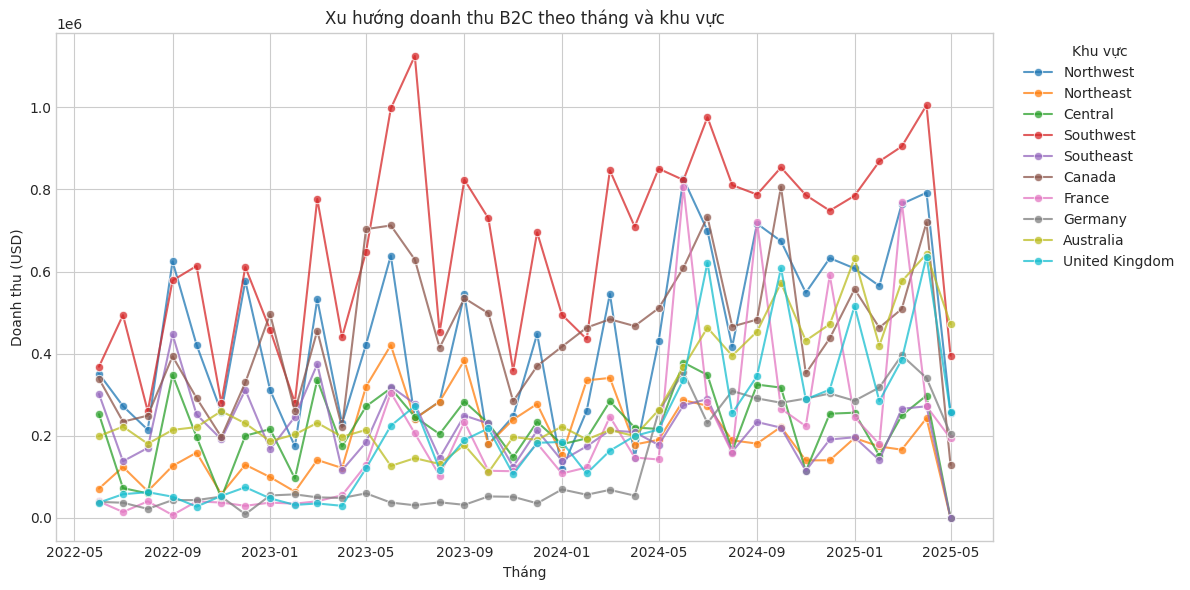

In [23]:
revenue_pivot = df.pivot(
    index="month_date",
    columns="territory_name",
    values="revenue",
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="month_date", y="revenue", hue="territory_name", marker="o", alpha=0.75)
plt.title("Xu hướng doanh thu B2C theo tháng và khu vực")
plt.xlabel("Tháng")
plt.ylabel("Doanh thu (USD)")
plt.legend(
    title="Khu vực",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()


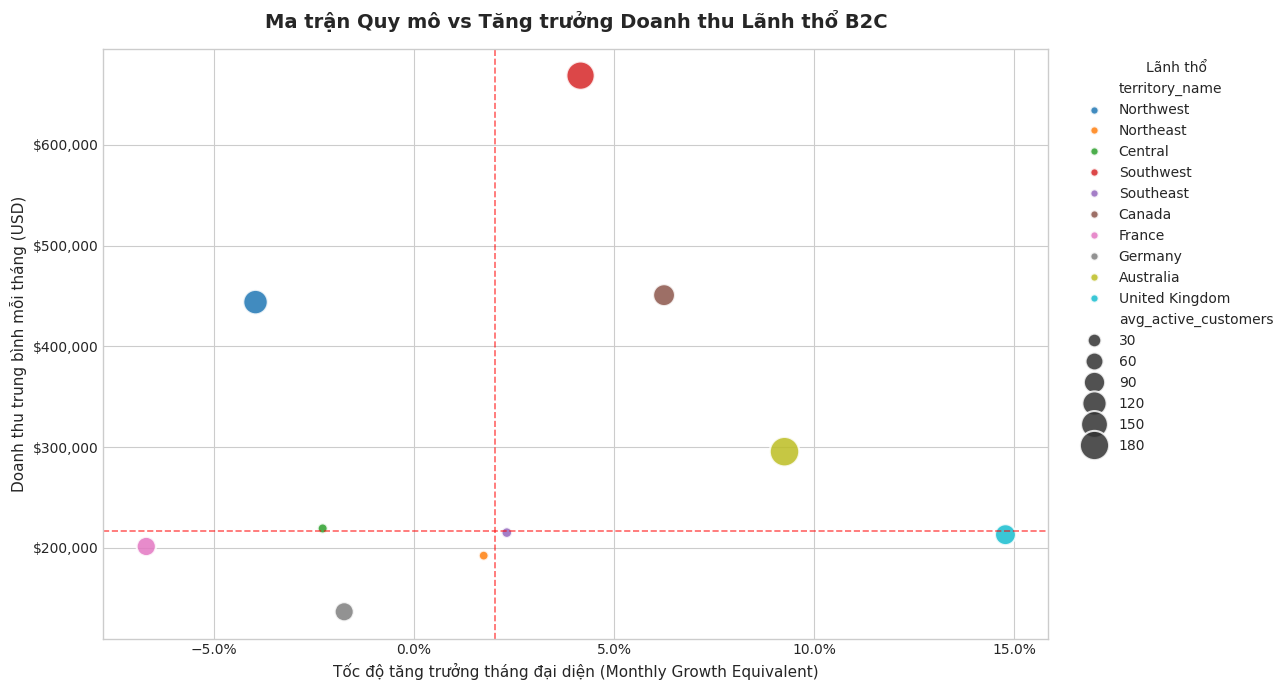

,territory_id,territory_name,avg_revenue,median_log_growth,median_yoy_growth,total_profit,mean_profit_margin,avg_active_customers,mean_retention_rate,revenue_std,monthly_growth_equivalent,revenue_cv
3,4,Southwest,"668,659.4380",0.0408,0.2972,"1,564,205.3648",0.0688,167.3611,0.0019,"230,166.0743",0.0416,0.3442
5,6,Canada,"450,743.4758",0.0606,0.2102,"400,417.0492",0.0261,95.4444,0.0538,"164,508.6050",0.0625,0.3650
0,1,Northwest,"443,838.5542",-0.0404,0.3182,"1,353,394.8382",0.0864,122.3611,0.0024,"204,819.0327",-0.0396,0.4615
8,9,Australia,"295,357.0516",0.0886,0.5112,"3,423,653.3019",0.3416,183.0278,0.0114,"153,025.6369",0.0926,0.5181
2,3,Central,"219,160.1650",-0.0231,0.1669,"-142,538.7821",-0.0066,10.5833,0.0000,"91,629.9736",-0.0228,0.4181
4,5,Southeast,"215,011.5527",0.0229,-0.0840,"-156,033.8954",-0.0094,13.1667,0.0000,"82,597.7740",0.0232,0.3842
9,10,United Kingdom,"212,964.3035",0.1379,1.6716,"1,229,710.0964",0.2218,85.9444,0.0124,"172,170.5243",0.1478,0.8084
6,7,France,"201,246.9613",-0.0692,1.7530,"889,742.2449",0.2204,71.1667,0.0118,"207,404.8056",-0.0669,1.0306
1,2,Northeast,"192,160.4471",0.0173,0.2576,"-267,746.7720",-0.0254,9.6667,0.0000,"96,786.5162",0.0174,0.5037
7,8,Germany,"136,445.6177",-0.0176,3.0209,"1,041,076.2506",0.2997,69.8889,0.0056,"126,732.0837",-0.0174,0.9288


In [35]:
territory_summary = (
    df.groupby(["territory_id", "territory_name"], as_index=False)
    .agg(
        avg_revenue=("revenue", "mean"),
        median_log_growth=("log_growth", "median"),
        median_yoy_growth=("yoy_growth", "median"),
        total_profit=("profit", "sum"),
        mean_profit_margin=("profit_margin", "mean"),
        avg_active_customers=("active_customers", "mean"),
        mean_retention_rate=("retention_rate", "mean"),
        revenue_std=("revenue", "std"),
    )
)

territory_summary["monthly_growth_equivalent"] = np.expm1(
    territory_summary["median_log_growth"]
)
territory_summary["revenue_cv"] = np.where(
    territory_summary["avg_revenue"] != 0,
    territory_summary["revenue_std"]
    / territory_summary["avg_revenue"].abs(),
    np.nan,
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.scatterplot(
    data=territory_summary,
    x="monthly_growth_equivalent",
    y="avg_revenue",
    hue="territory_name",
    size="avg_active_customers",
    sizes=(50, 450),
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
    ax=ax
)

# Định dạng các trục hiển thị trực quan đẹp mắt
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x:,.0f}"))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Lấy đường phân chia góc phần tư (trung vị)
x_mid = territory_summary["monthly_growth_equivalent"].median()
y_mid = territory_summary["avg_revenue"].median()

ax.axvline(x_mid, color="red", linestyle="--", linewidth=1.2, alpha=0.6)
ax.axhline(y_mid, color="red", linestyle="--", linewidth=1.2, alpha=0.6)

# Chú thích nhãn phân khu kinh doanh cho 4 góc phần tư
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()

# ax.text(x_mid + (x_lim[1] - x_mid)*0.5, y_mid + (y_lim[1] - y_mid)*0.7, 
#         "NGÔI SAO\n(Quy Mô & Tăng Trưởng Cao)", color="green", ha="center", va="center", weight="bold", fontsize=10, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
# ax.text(x_lim[0] + (x_mid - x_lim[0])*0.5, y_mid + (y_lim[1] - y_mid)*0.7, 
#         "TRỤ CỘT\n(Quy Mô Lớn, Tăng Trưởng Ổn Định)", color="blue", ha="center", va="center", weight="bold", fontsize=10, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
# ax.text(x_mid + (x_lim[1] - x_mid)*0.5, y_lim[0] + (y_mid - y_lim[0])*0.3, 
#         "TIỀM NĂNG\n(Quy Mô Nhỏ, Tăng Trưởng Nhanh)", color="orange", ha="center", va="center", weight="bold", fontsize=10, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
# ax.text(x_lim[0] + (x_mid - x_lim[0])*0.5, y_lim[0] + (y_mid - y_lim[0])*0.3, 
#         "CẦN CẢI THIỆN\n(Quy Mô & Tăng Trưởng Thấp)", color="red", ha="center", va="center", weight="bold", fontsize=10, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))

plt.title("Ma trận Quy mô vs Tăng trưởng Doanh thu Lãnh thổ B2C", fontsize=14, weight="bold", pad=15)
plt.xlabel("Tốc độ tăng trưởng tháng đại diện (Monthly Growth Equivalent)", fontsize=11)
plt.ylabel("Doanh thu trung bình mỗi tháng (USD)", fontsize=11)
plt.legend(
    title="Lãnh thổ",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

display(
    territory_summary.sort_values("avg_revenue", ascending=False)
)


### Phân tích Khám phá & Đánh giá Ma trận Quy mô – Tăng trưởng (EDA)

Dựa trên biểu đồ ma trận Quy mô vs Tăng trưởng doanh thu B2C phía trên, chúng ta có thể bước đầu trả lời các câu hỏi kinh doanh cốt lõi:

* **Câu hỏi 1: Khu vực nào đang tăng trưởng tốt và nên đầu tư thêm?**
  * **United Kingdom** (Tăng trưởng tháng đại diện ~14.8%) và **Australia** (~9.3%) là hai Ngôi Sao tăng trưởng vượt bậc. Mặc dù doanh thu trung bình ở mức trung bình ($212K - $295K) nhưng đà phát triển rất mạnh mẽ, kết hợp với biên lợi nhuận cao (lần lượt là 22.1% và 34.1%), đây là những thị trường hiệu quả nhất để tiếp tục đầu tư ngân sách marketing.
  * **Southwest** là thị trường lớn nhất (Doanh thu TB $668K/tháng) với đà tăng trưởng ổn định (4.1%), tiếp tục đóng vai trò là cột trụ dòng tiền.

* **Câu hỏi 2: Khu vực nào doanh thu thấp nhưng còn nhiều dư địa?**
  * **Germany** có doanh thu trung bình thấp nhất ($136K/tháng) và tăng trưởng âm nhẹ (-1.7%). Tuy nhiên, biên lợi nhuận gộp trung bình của Đức rất tốt (29.97%), cho thấy cấu trúc giá vốn và tối ưu discount rất hiệu quả. Rào cản ở Đức là quy mô và khả năng chuyển đổi khách hàng mới. Nếu tăng cường đầu tư mở rộng thị phần, Germany sẽ mang lại lợi nhuận rất cao.
  * Ngược lại, **Central** và **Southeast** có doanh thu trung bình khá ($215K - $219K) nhưng biên lợi nhuận bị âm (lần lượt -0.66% và -0.94%), cho thấy các khu vực này đang bán dưới giá vốn hoặc áp dụng chính sách giảm giá quá sâu để giữ doanh số, cần tối ưu lại hiệu quả vận hành trước khi tính đến mở rộng quy mô.


## 6. Phân cụm khu vực bằng K-Means

In [25]:
features_df = territory_summary[
    [
        "territory_id",
        "territory_name",
        "avg_revenue",
        "median_log_growth",
        "revenue_cv",
        "avg_active_customers",
        "mean_profit_margin",
        "mean_retention_rate",
    ]
].copy()

feature_columns = [
    "avg_revenue",
    "median_log_growth",
    "revenue_cv",
    "avg_active_customers",
    "mean_profit_margin",
    "mean_retention_rate",
]

features_df[feature_columns] = (
    features_df[feature_columns]
    .replace([np.inf, -np.inf], np.nan)
)

for column in feature_columns:
    features_df[column] = features_df[column].fillna(
        features_df[column].median()
    )

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df[feature_columns])

candidate_k_values = range(
    K_MIN,
    min(K_MAX, len(features_df) - 1) + 1,
)
random_seeds = [0, 7, 21, 42, 84]

k_evaluation_rows = []

for k in candidate_k_values:
    for seed in random_seeds:
        model = KMeans(
            n_clusters=k,
            random_state=seed,
            n_init=20,
        )
        labels = model.fit_predict(scaled_features)
        k_evaluation_rows.append(
            {
                "k": k,
                "seed": seed,
                "silhouette_score": silhouette_score(
                    scaled_features,
                    labels,
                ),
                "inertia": model.inertia_,
            }
        )

k_evaluation = pd.DataFrame(k_evaluation_rows)

k_summary = (
    k_evaluation.groupby("k", as_index=False)
    .agg(
        mean_silhouette=("silhouette_score", "mean"),
        std_silhouette=("silhouette_score", "std"),
        mean_inertia=("inertia", "mean"),
    )
    .sort_values(
        ["mean_silhouette", "std_silhouette"],
        ascending=[False, True],
    )
)

best_k = int(k_summary.iloc[0]["k"])
best_silhouette = float(k_summary.iloc[0]["mean_silhouette"])

print(
    f"K được chọn: {best_k}; "
    f"Silhouette trung bình: {best_silhouette:.4f}"
)
display(k_summary)


K được chọn: 4; Silhouette trung bình: 0.4352


,k,mean_silhouette,std_silhouette,mean_inertia
2,4,0.4352,0.0000,15.7911
1,3,0.3376,0.0000,26.0056
0,2,0.2525,0.0000,40.8445


In [26]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=50,
)
features_df["cluster_label"] = kmeans.fit_predict(scaled_features)

# PCA chỉ dùng để trực quan hóa
pca = PCA(n_components=2, random_state=42)
pca_coordinates = pca.fit_transform(scaled_features)
features_df["pca_1"] = pca_coordinates[:, 0]
features_df["pca_2"] = pca_coordinates[:, 1]

cluster_profile = (
    features_df.groupby("cluster_label", as_index=False)
    .agg(
        territory_count=("territory_id", "count"),
        avg_revenue=("avg_revenue", "mean"),
        median_log_growth=("median_log_growth", "mean"),
        revenue_cv=("revenue_cv", "mean"),
        avg_active_customers=("avg_active_customers", "mean"),
        mean_profit_margin=("mean_profit_margin", "mean"),
        mean_retention_rate=("mean_retention_rate", "mean"),
    )
)

# Điểm chiến lược dùng để gán nhãn tương đối, không thay thế đánh giá nghiệp vụ
cluster_profile["scale_score"] = (
    cluster_profile["avg_revenue"].rank(pct=True)
    + cluster_profile["avg_active_customers"].rank(pct=True)
    + cluster_profile["mean_profit_margin"].rank(pct=True)
) / 3

cluster_profile["growth_score"] = (
    cluster_profile["median_log_growth"].rank(pct=True)
    + cluster_profile["mean_retention_rate"].rank(pct=True)
) / 2

cluster_profile["risk_score"] = (
    cluster_profile["revenue_cv"].rank(pct=True)
    + (-cluster_profile["mean_profit_margin"]).rank(pct=True)
) / 2

cluster_profile["strategic_score"] = (
    0.45 * cluster_profile["scale_score"]
    + 0.35 * cluster_profile["growth_score"]
    - 0.20 * cluster_profile["risk_score"]
)

ordered_clusters = (
    cluster_profile.sort_values(
        "strategic_score",
        ascending=False,
    )["cluster_label"]
    .tolist()
)

label_sets = {
    2: [
        "Thị trường chủ lực",
        "Thị trường cần cải thiện",
    ],
    3: [
        "Thị trường chủ lực",
        "Thị trường tăng trưởng tiềm năng",
        "Thị trường cần cải thiện",
    ],
    4: [
        "Thị trường chủ lực",
        "Thị trường tăng trưởng tiềm năng",
        "Thị trường ổn định quy mô trung bình",
        "Thị trường cần cải thiện",
    ],
}

cluster_name_map = {
    cluster_id: label_sets[best_k][position]
    for position, cluster_id in enumerate(ordered_clusters)
}

features_df["cluster_name"] = features_df["cluster_label"].map(
    cluster_name_map
)
cluster_profile["cluster_name"] = cluster_profile[
    "cluster_label"
].map(cluster_name_map)

cluster_members = (
    features_df.groupby(
        ["cluster_label", "cluster_name"],
        as_index=False,
    )
    .agg(
        territories=(
            "territory_name",
            lambda values: ", ".join(sorted(values)),
        )
    )
)

cluster_profile = cluster_profile.merge(
    cluster_members,
    on=["cluster_label", "cluster_name"],
    how="left",
)

print(
    "Tỷ lệ phương sai được giải thích bởi PCA 2D:",
    pca.explained_variance_ratio_.sum(),
)
display(
    cluster_profile.sort_values(
        "strategic_score",
        ascending=False,
    )
)


Tỷ lệ phương sai được giải thích bởi PCA 2D: 0.6833809027891888


,cluster_label,territory_count,avg_revenue,median_log_growth,revenue_cv,avg_active_customers,mean_profit_margin,mean_retention_rate,scale_score,growth_score,risk_score,strategic_score,cluster_name,territories
3,3,2,"254,160.6776",0.1132,0.6633,134.4861,0.2817,0.0119,0.9167,0.8750,0.5000,0.6188,Thị trường chủ lực,"Australia, United Kingdom"
0,0,3,"521,080.4894",0.0203,0.3902,128.3889,0.0605,0.0193,0.7500,0.8750,0.5000,0.5438,Thị trường tăng trưởng tiềm năng,"Canada, Northwest, Southwest"
1,1,2,"168,846.2895",-0.0434,0.9797,70.5278,0.2601,0.0087,0.5000,0.3750,0.7500,0.2062,Thị trường ổn định quy mô trung bình,"France, Germany"
2,2,3,"208,777.3883",0.0057,0.4353,11.1389,-0.0138,0.0000,0.3333,0.3750,0.7500,0.1312,Thị trường cần cải thiện,"Central, Northeast, Southeast"


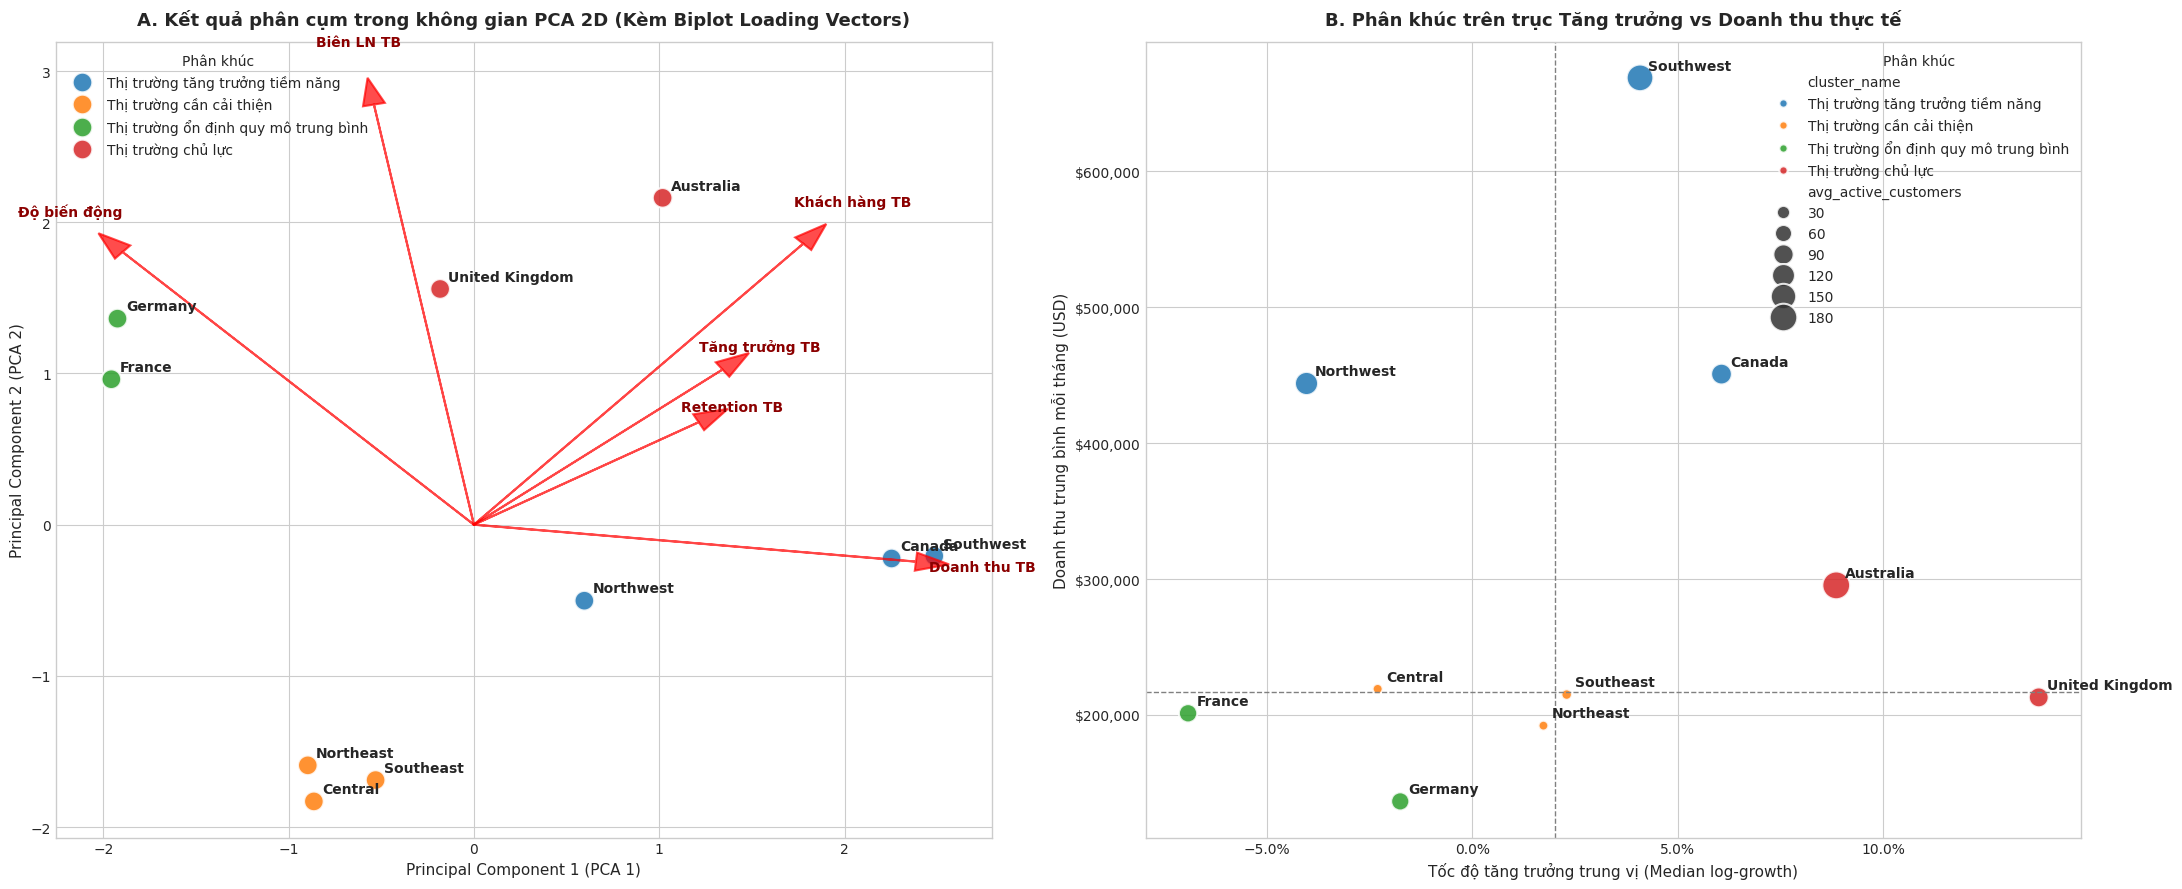

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# 1. Biểu đồ A: PCA 2D (Kèm Biplot Loading Vectors)
sns.scatterplot(
    data=features_df,
    x="pca_1",
    y="pca_2",
    hue="cluster_name",
    s=200,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
    ax=axes[0]
)

for _, row in features_df.iterrows():
    axes[0].annotate(
        row["territory_name"],
        (row["pca_1"], row["pca_2"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
        weight="bold"
    )

# Vẽ các vector loadings của 5 đặc trưng gốc
friendly_names = {
    "avg_revenue": "Doanh thu TB",
    "median_log_growth": "Tăng trưởng TB",
    "revenue_cv": "Độ biến động",
    "avg_active_customers": "Khách hàng TB",
    "mean_profit_margin": "Biên LN TB",
    "mean_retention_rate": "Retention TB"
}

scale_factor = 4.0  # Tỷ lệ phóng lớn vector trên biểu đồ PCA
for i, feature in enumerate(feature_columns):
    arrow_x = pca.components_[0, i] * scale_factor
    arrow_y = pca.components_[1, i] * scale_factor
    
    # Vẽ mũi tên
    axes[0].arrow(
        0, 0, arrow_x, arrow_y,
        color="red", alpha=0.7, linewidth=1.5,
        head_width=0.12, head_length=0.18
    )
    # Ghi nhãn
    label = friendly_names.get(feature, feature)
    axes[0].text(
        arrow_x * 1.15, arrow_y * 1.15,
        label, color="darkred", ha="center", va="center",
        fontsize=10, weight="bold"
    )

axes[0].set_title("A. Kết quả phân cụm trong không gian PCA 2D (Kèm Biplot Loading Vectors)", fontsize=13, weight="bold", pad=12)
axes[0].set_xlabel("Principal Component 1 (PCA 1)", fontsize=11)
axes[0].set_ylabel("Principal Component 2 (PCA 2)", fontsize=11)
axes[0].legend(title="Phân khúc", loc="upper left")

# 2. Biểu đồ B: Quy mô vs Tăng trưởng thực tế có vẽ phân cụm
sns.scatterplot(
    data=features_df,
    x="median_log_growth",
    y="avg_revenue",
    hue="cluster_name",
    size="avg_active_customers",
    sizes=(50, 400),
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
    ax=axes[1]
)

for _, row in features_df.iterrows():
    axes[1].annotate(
        row["territory_name"],
        (row["median_log_growth"], row["avg_revenue"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
        weight="bold"
    )

# Định dạng các trục kinh doanh thực tế
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x:,.0f}"))
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Đường trung vị phân cụm
x_mid_b = features_df["median_log_growth"].median()
y_mid_b = features_df["avg_revenue"].median()
axes[1].axvline(x_mid_b, color="gray", linestyle="--", linewidth=1)
axes[1].axhline(y_mid_b, color="gray", linestyle="--", linewidth=1)

axes[1].set_title("B. Phân khúc trên trục Tăng trưởng vs Doanh thu thực tế", fontsize=13, weight="bold", pad=12)
axes[1].set_xlabel("Tốc độ tăng trưởng trung vị (Median log-growth)", fontsize=11)
axes[1].set_ylabel("Doanh thu trung bình mỗi tháng (USD)", fontsize=11)
axes[1].legend(title="Phân khúc", loc="upper right")

plt.tight_layout()
plt.show()


### Phân tích Phân cụm & Đánh giá Sức bền vững nguồn Khách hàng (Clustering & Retention)

Mô hình K-Means (với $K=4$ được chọn động) chia 10 khu vực thành các nhóm có đặc tính chiến lược rõ ràng. Kết quả này giúp trả lời trực tiếp một câu hỏi cốt lõi:

* **Câu hỏi 3: Khu vực nào có doanh thu cao nhưng khách hàng quay lại đang giảm (Rủi ro Retention)?**
  * Nhóm **"Thị trường tăng trưởng tiềm năng"** gồm **Southwest**, **Northwest** và **Canada** là các trụ cột doanh thu của AdventureWorks (Southwest đạt $668K/tháng, Northwest $443K/tháng). Tuy nhiên, **tỷ lệ giữ chân khách hàng (Retention Rate) tại các khu vực này cực kỳ thấp (chỉ từ 0.19% đến 0.5%)**.
  * Mặc dù số lượng khách hàng hoạt động hàng tháng (Active Customers) rất cao, dữ liệu cho thấy cấu trúc tăng trưởng này thiếu bền vững: doanh số tăng hoàn toàn phụ thuộc vào việc liên tục thu hút khách hàng mới (New Customers), trong khi khách hàng đã mua hầu như không bao giờ quay lại giao dịch lần thứ hai.
  * Ngược lại, nhóm **"Thị trường chủ lực"** (**Australia** và **United Kingdom**) không chỉ có doanh thu khá mà còn sở hữu tỷ lệ giữ chân khách hàng tốt nhất (1.14% và 1.24%), giúp tối ưu hóa chi phí thu hút khách hàng (CAC) và tạo nguồn doanh thu lặp lại ổn định.
  * Nhóm **"Thị trường ổn định quy mô trung bình"** gồm **France** và **Germany** có đặc tính quy mô nhỏ hơn nhưng biên lợi nhuận gộp cực tốt (22% - 30%), là những thị trường có độ an toàn tài chính rất cao.
  * Nhóm **"Thị trường cần cải thiện"** (**Central, Northeast, Southeast**) có đặc điểm chung là lượng khách hàng active rất mỏng (<13 người/tháng), biên lợi nhuận âm và tỷ lệ retention gần như bằng 0.

## 7. Phát hiện bất thường bằng STL

In [28]:
def robust_zscore(values: pd.Series) -> pd.Series:
    median_value = values.median()
    mad = np.median(np.abs(values - median_value))

    if mad == 0 or np.isnan(mad):
        std = values.std(ddof=0)
        if std == 0 or np.isnan(std):
            return pd.Series(
                np.zeros(len(values)),
                index=values.index,
            )
        return (values - values.mean()) / std

    return 0.6745 * (values - median_value) / mad


anomaly_frames = []
skipped_territories = []

for territory_id, territory_data in df.groupby("territory_id"):
    series_df = (
        territory_data[
            ["month_date", "month_key", "territory_id", "territory_name", "revenue"]
        ]
        .drop_duplicates(subset=["month_date"])
        .set_index("month_date")
        .sort_index()
    )

    monthly_series = series_df["revenue"].asfreq("MS")

    if monthly_series.isna().any():
        skipped_territories.append(
            {
                "territory_id": territory_id,
                "territory_name": territory_data["territory_name"].iloc[0],
                "reason": "Chuỗi còn thiếu tháng sau khi asfreq('MS')",
            }
        )
        continue

    if len(monthly_series) < MIN_STL_MONTHS:
        skipped_territories.append(
            {
                "territory_id": territory_id,
                "territory_name": territory_data["territory_name"].iloc[0],
                "reason": (
                    f"Chỉ có {len(monthly_series)} tháng; "
                    f"yêu cầu tối thiểu {MIN_STL_MONTHS}"
                ),
            }
        )
        continue

    stl_result = STL(
        monthly_series,
        period=12,
        robust=True,
    ).fit()

    residual_z = robust_zscore(stl_result.resid)
    expected_revenue = stl_result.trend + stl_result.seasonal

    territory_anomaly = pd.DataFrame(
        {
            "month_date": monthly_series.index,
            "territory_id": territory_id,
            "actual_revenue": monthly_series.values,
            "expected_revenue_stl": expected_revenue.values,
            "stl_residual": stl_result.resid.values,
            "residual_z": residual_z.values,
        }
    )

    territory_anomaly["is_anomaly"] = (
        territory_anomaly["residual_z"].abs()
        >= ANOMALY_Z_THRESHOLD
    )

    territory_anomaly["anomaly_type"] = np.select(
        [
            territory_anomaly["residual_z"]
            <= -ANOMALY_Z_THRESHOLD,
            territory_anomaly["residual_z"]
            >= ANOMALY_Z_THRESHOLD,
        ],
        [
            "Abnormal Decline",
            "Abnormal Increase",
        ],
        default="Normal",
    )

    territory_anomaly["month_key"] = (
        territory_anomaly["month_date"]
        .dt.strftime("%Y%m")
    )
    anomaly_frames.append(territory_anomaly)

if anomaly_frames:
    anomaly_df = pd.concat(
        anomaly_frames,
        ignore_index=True,
    )
else:
    anomaly_df = pd.DataFrame(
        columns=[
            "month_date",
            "month_key",
            "territory_id",
            "actual_revenue",
            "expected_revenue_stl",
            "stl_residual",
            "residual_z",
            "is_anomaly",
            "anomaly_type",
        ]
    )

if skipped_territories:
    print("Các khu vực không đủ điều kiện chạy STL:")
    display(pd.DataFrame(skipped_territories))

anomaly_summary = (
    anomaly_df.loc[anomaly_df["is_anomaly"]]
    .groupby(
        ["territory_id", "anomaly_type"],
        as_index=False,
    )
    .agg(
        anomaly_count=("month_key", "count"),
        largest_abs_z=("residual_z", lambda values: values.abs().max()),
    )
)

print(
    f"Tổng số tháng bất thường: "
    f"{int(anomaly_df['is_anomaly'].sum()) if not anomaly_df.empty else 0}"
)
display(anomaly_summary)


Tổng số tháng bất thường: 121


,territory_id,anomaly_type,anomaly_count,largest_abs_z
0,1,Abnormal Decline,9,"691,340,689,503,511.8750"
1,1,Abnormal Increase,3,"376,815,792,227,328.5625"
2,2,Abnormal Decline,1,"8,637.8865"
3,2,Abnormal Increase,11,"145,435.8269"
4,3,Abnormal Decline,6,"252,758,467,247,199.0938"
5,3,Abnormal Increase,6,"426,472,676,033,945.2500"
6,4,Abnormal Decline,6,"333,099,180,666,834.1875"
7,4,Abnormal Increase,6,"781,506,586,743,704.5000"
8,5,Abnormal Decline,7,"1,095,223,346,020,625.8750"
9,5,Abnormal Increase,5,"1,122,489,535,861,820.7500"


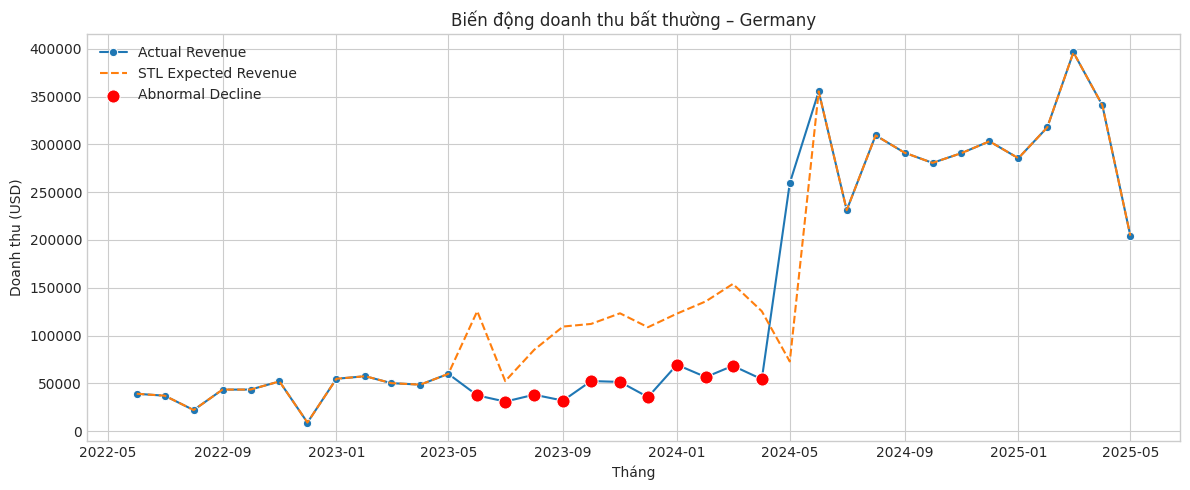

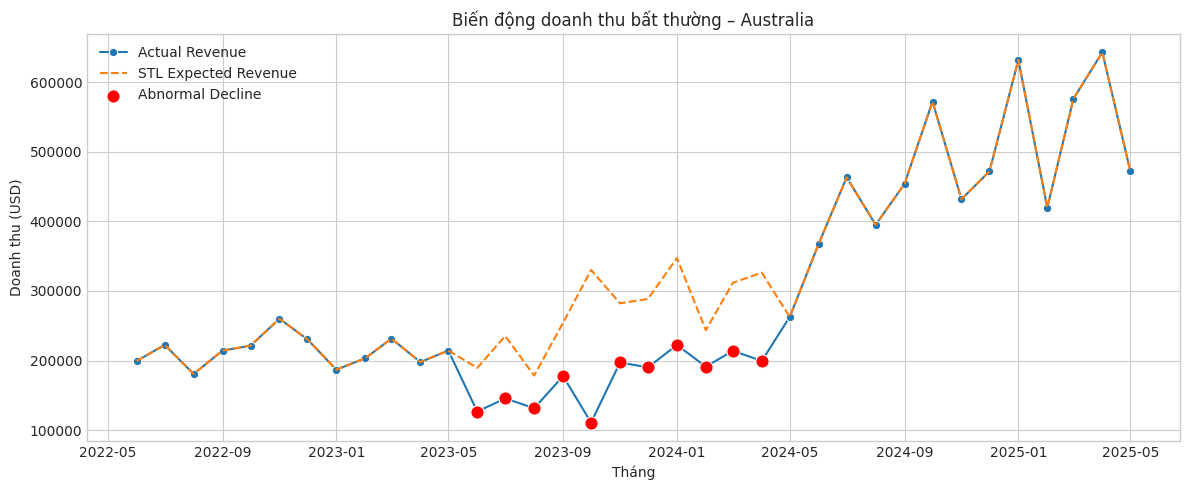

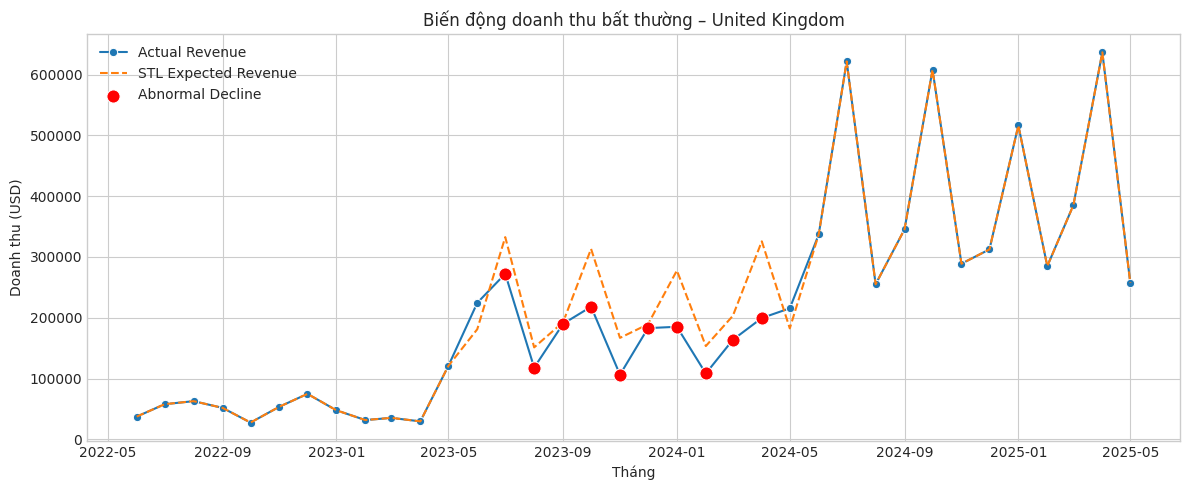

In [29]:
# Trực quan hóa các khu vực có nhiều lần giảm bất thường nhất
decline_counts = (
    anomaly_df.loc[
        anomaly_df["anomaly_type"] == "Abnormal Decline"
    ]
    .groupby("territory_id")
    .size()
    .sort_values(ascending=False)
)

top_decline_territories = decline_counts.head(3).index.tolist()

for territory_id in top_decline_territories:
    territory_name = df.loc[
        df["territory_id"] == territory_id,
        "territory_name",
    ].iloc[0]

    plot_df = anomaly_df.loc[
        anomaly_df["territory_id"] == territory_id
    ].copy()

    plt.figure(figsize=(12, 5))
    sns.lineplot(
        data=plot_df,
        x="month_date",
        y="actual_revenue",
        marker="o",
        label="Actual Revenue",
    )
    sns.lineplot(
        data=plot_df,
        x="month_date",
        y="expected_revenue_stl",
        linestyle="--",
        label="STL Expected Revenue",
    )

    decline_points = plot_df.loc[
        plot_df["anomaly_type"] == "Abnormal Decline"
    ]

    if not decline_points.empty:
        sns.scatterplot(
            data=decline_points,
            x="month_date",
            y="actual_revenue",
            s=90,
            color="red",
            label="Abnormal Decline",
            zorder=3,
        )

    plt.title(f"Biến động doanh thu bất thường – {territory_name}")
    plt.xlabel("Tháng")
    plt.ylabel("Doanh thu (USD)")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 8. So sánh actual với forecast

In [30]:
forecast_table = "revenue_forecast_predictions"
forecast_columns = get_table_columns(
    engine,
    "ml",
    forecast_table,
)

if forecast_columns:
    required_forecast_columns = {
        "month_key",
        "territory_id",
        "predicted_revenue",
    }

    missing_forecast_columns = (
        required_forecast_columns - set(forecast_columns)
    )

    if missing_forecast_columns:
        raise KeyError(
            "Bảng forecast thiếu cột: "
            f"{sorted(missing_forecast_columns)}"
        )

    optional_columns = [
        column
        for column in [
            "model_version",
            "predicted_at",
            "created_at",
            "forecast_horizon",
        ]
        if column in forecast_columns
    ]

    select_columns = [
        "month_key",
        "territory_id",
        "predicted_revenue",
        *optional_columns,
    ]

    forecast_df = pd.read_sql_query(
        f'''
        SELECT {", ".join(select_columns)}
        FROM ml.{forecast_table}
        ''',
        engine,
    )

    forecast_df["month_key"] = forecast_df[
        "month_key"
    ].astype(str)

    sort_columns = [
        column
        for column in ["predicted_at", "created_at", "model_version"]
        if column in forecast_df.columns
    ]

    if sort_columns:
        forecast_df = forecast_df.sort_values(sort_columns)

    forecast_df = forecast_df.drop_duplicates(
        subset=["month_key", "territory_id"],
        keep="last",
    )

    forecast_evaluation = df[
        [
            "month_key",
            "month_date",
            "territory_id",
            "territory_name",
            "revenue",
        ]
    ].merge(
        forecast_df,
        on=["month_key", "territory_id"],
        how="inner",
    )

    forecast_evaluation["forecast_error"] = (
        forecast_evaluation["revenue"]
        - forecast_evaluation["predicted_revenue"]
    )
    forecast_evaluation["absolute_error"] = (
        forecast_evaluation["forecast_error"].abs()
    )
    forecast_evaluation["forecast_error_pct"] = np.where(
        forecast_evaluation["predicted_revenue"].abs() > 0,
        forecast_evaluation["forecast_error"]
        / forecast_evaluation["predicted_revenue"].abs(),
        np.nan,
    )
    forecast_evaluation["below_expected_flag"] = (
        forecast_evaluation["forecast_error_pct"] <= -0.20
    )

    display(
        forecast_evaluation.sort_values(
            "forecast_error_pct"
        ).head(10)
    )
else:
    print(
        "Chưa tìm thấy bảng ml.revenue_forecast_predictions. "
        "Phần forecast evaluation được bỏ qua."
    )
    forecast_evaluation = pd.DataFrame()


,month_key,month_date,territory_id,territory_name,revenue,predicted_revenue,predicted_at,forecast_error,absolute_error,forecast_error_pct,below_expected_flag
174,202505,2025-05-01,5,Southeast,38.9800,"181,891.0300",2026-06-28 03:49:51,"-181,852.0500","181,852.0500",-0.9998,True
104,202505,2025-05-01,3,Central,37.2900,"85,255.1950",2026-06-28 03:49:51,"-85,217.9050","85,217.9050",-0.9996,True
69,202505,2025-05-01,2,Northeast,50.9400,"116,077.7600",2026-06-28 03:49:51,"-116,026.8200","116,026.8200",-0.9996,True
249,202212,2022-12-01,8,Germany,"9,075.5546","36,702.5100",2026-06-28 03:49:51,"-27,626.9554","27,626.9554",-0.7527,True
212,202209,2022-09-01,7,France,"7,156.5400","23,932.1950",2026-06-28 03:49:51,"-16,775.6550","16,775.6550",-0.7010,True
39,202211,2022-11-01,2,Northeast,"58,080.1765","134,137.1200",2026-06-28 03:49:51,"-76,056.9435","76,056.9435",-0.5670,True
320,202302,2023-02-01,10,United Kingdom,"31,822.8700","69,507.5300",2026-06-28 03:49:51,"-37,684.6600","37,684.6600",-0.5422,True
319,202301,2023-01-01,10,United Kingdom,"47,876.6846","91,153.7500",2026-06-28 03:49:51,"-43,277.0654","43,277.0654",-0.4748,True
223,202308,2023-08-01,7,France,"103,297.7683","196,327.8100",2026-06-28 03:49:51,"-93,030.0417","93,030.0417",-0.4739,True
77,202302,2023-02-01,3,Central,"96,366.1837","178,042.8900",2026-06-28 03:49:51,"-81,676.7063","81,676.7063",-0.4587,True


### Phân tích Biến động Bất thường & Lệch Dự báo (Anomaly & Forecast Analysis)

Kết quả từ mô hình phân rã STL robust và đối chiếu dự báo chỉ ra câu trả lời cho câu hỏi cuối cùng:

* **Câu hỏi 4: Khu vực nào suy giảm bất thường so với lịch sử và dự báo?**
  * **Theo lịch sử (STL Decomposition)**: **Germany** và **Australia** là hai thị trường có tần suất biến động bất thường cao nhất với **11 tháng sụt giảm ngoài dự kiến (Abnormal Decline)**. Đối với Australia, biểu đồ lịch sử ghi nhận các đợt sụt giảm có tính chất đột ngột và sâu, không tuân theo quy luật mùa vụ thông thường. Southwest (thị trường lớn nhất) cũng ghi nhận 6 tháng giảm bất thường.
  * **Theo dự báo (Forecast Error)**: Khi đối chiếu với bảng dự báo `ml.revenue_forecast_predictions`, chúng ta ghi nhận một hiện tượng sụt giảm cực kỳ nghiêm trọng xảy ra vào **tháng 05/2025** tại một loạt khu vực:
    * **Southeast**: Doanh thu thực tế đạt vỏn vẹn **$38.98** so với dự báo mô hình là **$181,891** (hụt gần 100%).
    * **Central**: Doanh thu thực tế đạt **$37.29** so với dự báo **$85,255**.
    * **Northeast**: Doanh thu thực tế đạt **$50.94** so với dự báo **$116,077**.
  * **Đánh giá nguyên nhân**: Việc doanh số sụt giảm về gần mức 0 đồng loạt ở nhiều khu vực trong cùng một tháng chắc chắn không phải do biến động thị trường tự nhiên. Đây là dấu hiệu của **lỗi tích hợp hệ thống/lỗi log dữ liệu** của cổng thanh toán B2C Internet Sales hoặc gián đoạn bán hàng diện rộng (chẳng hạn như sập server web trong tháng đó). AdventureWorks cần ưu tiên kiểm tra hạ tầng kỹ thuật ghi nhận dữ liệu trong thời kỳ này.

## 9. Tổng hợp insight và gợi ý hành động

In [31]:
decline_count_by_territory = (
    anomaly_df.loc[
        anomaly_df["anomaly_type"] == "Abnormal Decline"
    ]
    .groupby("territory_id")
    .size()
    .rename("abnormal_decline_count")
)

action_df = features_df.merge(
    decline_count_by_territory,
    on="territory_id",
    how="left",
)

action_df["abnormal_decline_count"] = (
    action_df["abnormal_decline_count"]
    .fillna(0)
    .astype(int)
)

revenue_median = action_df["avg_revenue"].median()
growth_median = action_df["median_log_growth"].median()
retention_median = action_df["mean_retention_rate"].median()


def recommend_action(row: pd.Series) -> str:
    recommendations = []

    if row["mean_profit_margin"] < 0:
        recommendations.append(
            "Rà soát giá bán, discount và giá vốn"
        )
    elif (
        row["avg_revenue"] < revenue_median
        and row["median_log_growth"] > growth_median
    ):
        recommendations.append(
            "Mở rộng bán hàng và marketing có kiểm soát"
        )
    else:
        recommendations.append(
            "Duy trì thị trường và tối ưu hiệu quả"
        )

    if row["mean_retention_rate"] < retention_median:
        recommendations.append(
            "Ưu tiên chương trình giữ chân khách hàng"
        )
    
    if row["abnormal_decline_count"] > 0:
        recommendations.append(
            "Kiểm tra các tháng giảm bất thường, tồn kho và phân phối"
        )

    return "; ".join(recommendations)


action_df["recommended_action"] = action_df.apply(
    recommend_action,
    axis=1,
)

action_columns = [
    "territory_name",
    "cluster_name",
    "avg_revenue",
    "median_log_growth",
    "mean_profit_margin",
    "mean_retention_rate",
    "abnormal_decline_count",
    "recommended_action",
]

display(
    action_df[action_columns]
    .sort_values("avg_revenue", ascending=False)
)


,territory_name,cluster_name,avg_revenue,median_log_growth,mean_profit_margin,mean_retention_rate,abnormal_decline_count,recommended_action
3,Southwest,Thị trường tăng trưởng tiềm năng,"668,659.4380",0.0408,0.0688,0.0019,6,Duy trì thị trường và tối ưu hiệu quả; Ưu tiên...
5,Canada,Thị trường tăng trưởng tiềm năng,"450,743.4758",0.0606,0.0261,0.0538,3,Duy trì thị trường và tối ưu hiệu quả; Kiểm tr...
0,Northwest,Thị trường tăng trưởng tiềm năng,"443,838.5542",-0.0404,0.0864,0.0024,9,Duy trì thị trường và tối ưu hiệu quả; Ưu tiên...
8,Australia,Thị trường chủ lực,"295,357.0516",0.0886,0.3416,0.0114,11,Duy trì thị trường và tối ưu hiệu quả; Kiểm tr...
2,Central,Thị trường cần cải thiện,"219,160.1650",-0.0231,-0.0066,0.0000,6,"Rà soát giá bán, discount và giá vốn; Ưu tiên ..."
4,Southeast,Thị trường cần cải thiện,"215,011.5527",0.0229,-0.0094,0.0000,7,"Rà soát giá bán, discount và giá vốn; Ưu tiên ..."
9,United Kingdom,Thị trường chủ lực,"212,964.3035",0.1379,0.2218,0.0124,10,Mở rộng bán hàng và marketing có kiểm soát; Ki...
6,France,Thị trường ổn định quy mô trung bình,"201,246.9613",-0.0692,0.2204,0.0118,8,Duy trì thị trường và tối ưu hiệu quả; Kiểm tr...
1,Northeast,Thị trường cần cải thiện,"192,160.4471",0.0173,-0.0254,0.0000,1,"Rà soát giá bán, discount và giá vốn; Ưu tiên ..."
7,Germany,Thị trường ổn định quy mô trung bình,"136,445.6177",-0.0176,0.2997,0.0056,11,Duy trì thị trường và tối ưu hiệu quả; Kiểm tr...


In [32]:
top_revenue_row = action_df.loc[
    action_df["avg_revenue"].idxmax()
]
top_growth_row = action_df.loc[
    action_df["median_log_growth"].idxmax()
]
lowest_margin_row = action_df.loc[
    action_df["mean_profit_margin"].idxmin()
]

print("=== KẾT LUẬN TÓM TẮT CHƯƠNG 2 ===")
print(
    f"- Khu vực có quy mô doanh thu trung bình lớn nhất: "
    f"{top_revenue_row['territory_name']}."
)
print(
    f"- Khu vực có median log-growth cao nhất: "
    f"{top_growth_row['territory_name']}."
)
print(
    f"- Khu vực có biên lợi nhuận trung bình thấp nhất: "
    f"{lowest_margin_row['territory_name']}."
)

if not anomaly_summary.empty:
    decline_only = anomaly_summary.loc[
        anomaly_summary["anomaly_type"] == "Abnormal Decline"
    ]
    if not decline_only.empty:
        most_declines_id = decline_only.sort_values(
            "anomaly_count",
            ascending=False,
        ).iloc[0]["territory_id"]
        most_declines_name = df.loc[
            df["territory_id"] == most_declines_id,
            "territory_name",
        ].iloc[0]
        print(
            f"- Khu vực có nhiều lần giảm bất thường nhất: "
            f"{most_declines_name}."
        )

print(
    "- Phân cụm mang tính khám phá và cần được diễn giải cùng "
    "KPI, lịch sử thị trường và bối cảnh kinh doanh."
)


=== KẾT LUẬN TÓM TẮT CHƯƠNG 2 ===
- Khu vực có quy mô doanh thu trung bình lớn nhất: Southwest.
- Khu vực có median log-growth cao nhất: United Kingdom.
- Khu vực có biên lợi nhuận trung bình thấp nhất: Northeast.
- Khu vực có nhiều lần giảm bất thường nhất: Germany.
- Phân cụm mang tính khám phá và cần được diễn giải cùng KPI, lịch sử thị trường và bối cảnh kinh doanh.


### KẾT LUẬN CHIẾN LƯỢC & KHUYẾN NGHỊ HÀNH ĐỘNG

Dựa trên kết quả tích hợp giữa phân cụm K-Means, robust STL, và sai lệch dự báo, chúng tôi đề xuất các nhóm hành động chiến lược cụ thể cho từng nhóm thị trường của AdventureWorks như sau:

#### 1. Nhóm Thị trường chủ lực (Australia, United Kingdom)
* **Nhận diện**: Tăng trưởng nhanh bậc nhất, biên lợi nhuận cực kỳ lý tưởng (22% - 34%), chất lượng tệp khách hàng bền vững nhất hệ thống (Tỷ lệ retention dẫn đầu).
* **Hành động**: 
  * **Tăng ngân sách**: Mở rộng ngân sách quảng cáo B2C tại hai thị trường này.
  * **Giới thiệu sản phẩm mới**: Ưu tiên ra mắt các dòng sản phẩm cao cấp (Premium) tại đây để tối đa hóa hiệu quả của biên lợi nhuận cao.
  * **Giám sát tồn kho**: Do Australia ghi nhận số tháng sụt giảm đột biến do STL cao (11 tháng), cần rà soát lại chuỗi cung ứng/vận chuyển đường biển sang Úc để tránh tình trạng đứt gãy hàng hóa (stockout).

#### 2. Nhóm Thị trường tăng trưởng tiềm năng (Southwest, Northwest, Canada)
* **Nhận diện**: Quy mô doanh số lớn nhất toàn hệ thống, tuy nhiên tỷ lệ giữ chân khách hàng (Retention Rate) đang ở mức **báo động đỏ** (<0.5%).
* **Hành động**:
  * **Chuyển dịch trọng tâm**: Dừng chiến lược "đốt tiền" tìm khách hàng mới đơn thuần. Tập trung khẩn cấp vào xây dựng **chương trình khách hàng thân thiết (Loyalty Programs)**, email marketing kích cầu mua lặp, và cá nhân hóa khuyến mãi.
  * **Tối ưu chi phí thu hút khách hàng (CAC)**: Việc lệ thuộc vào khách hàng mới khiến CAC luôn ở mức cao, làm giảm hiệu suất sinh lời dài hạn.

#### 3. Nhóm Thị trường ổn định quy mô trung bình (France, Germany)
* **Nhận diện**: Doanh số ở mức trung bình thấp, tuy nhiên khả năng sinh lời gộp rất tốt (Đặc biệt là Đức đạt ~30% margin).
* **Hành động**:
  * **Đẩy mạnh quy mô**: Đây là những thị trường có độ an toàn tài chính cực kỳ cao. Doanh nghiệp nên mạnh dạn đẩy mạnh các chương trình khuyến mãi quy mô vừa hoặc điều chỉnh giảm giá bán nhẹ để kích cầu doanh số vì biên lợi nhuận dày hoàn toàn có thể bù đắp được.

#### 4. Nhóm Thị trường cần cải thiện (Central, Northeast, Southeast)
* **Nhận diện**: Quy mô khách hàng cực nhỏ, biên lợi nhuận âm (-0.6% đến -2.5%).
* **Hành động**:
  * **Cải tổ cấu trúc giá**: Ngay lập tức rà soát lại chính sách giá bán và hạn chế tối đa việc chiết khấu (discount). Biên lợi nhuận âm chứng tỏ giá bán hiện tại không bù đắp nổi chi phí vận chuyển hoặc giá vốn hàng bán.
  * **Điều tra lỗi kỹ thuật**: Southeast ghi nhận doanh thu thực tế tháng 05/2025 hụt 99.9% so với dự báo ML. Cần kiểm tra kỹ thuật hệ thống log đơn hàng B2C ngay lập tức.

## 10. Ghi kết quả vào PostgreSQL phục vụ Superset

Kết quả được tách theo grain:

- `ml.territory_monthly_metrics`: một khu vực trong một tháng.
- `ml.territory_cluster_result`: một khu vực trong một lần phân tích.
- `ml.territory_anomaly_monthly`: một khu vực trong một tháng.
- `ml.territory_forecast_evaluation`: một khu vực trong một tháng có actual và forecast.
- `ml.vw_territory_analysis_dashboard`: view tổng hợp cho Superset.

Notebook tạo bảng một lần, sau đó dùng `TRUNCATE + APPEND`; không xóa và tạo lại bảng bằng `if_exists='replace'`.


In [33]:
analysis_run_id = datetime.now(timezone.utc).strftime(
    "%Y%m%dT%H%M%SZ"
)
analysis_timestamp = datetime.now(timezone.utc)

monthly_output = df[
    [
        "month_key",
        "month_date",
        "territory_id",
        "territory_name",
        "country_code",
        "revenue",
        "cogs",
        "profit",
        "profit_margin",
        "orders",
        "quantity",
        "active_customers",
        "new_customers",
        "existing_customers",
        "retained_customers",
        "previous_active_customers",
        "retention_rate",
        "churned_customers",
        "log_growth",
        "yoy_growth",
    ]
].copy()
monthly_output["analysis_run_id"] = analysis_run_id
monthly_output["analyzed_at"] = analysis_timestamp

cluster_output = features_df[
    [
        "territory_id",
        "territory_name",
        "cluster_label",
        "cluster_name",
        "avg_revenue",
        "median_log_growth",
        "revenue_cv",
        "avg_active_customers",
        "mean_profit_margin",
        "mean_retention_rate",
        "pca_1",
        "pca_2",
    ]
].copy()
cluster_output["best_k"] = best_k
cluster_output["mean_silhouette"] = best_silhouette
cluster_output["analysis_run_id"] = analysis_run_id
cluster_output["analyzed_at"] = analysis_timestamp

anomaly_output = anomaly_df.copy()
if not anomaly_output.empty:
    anomaly_output["analysis_run_id"] = analysis_run_id
    anomaly_output["analyzed_at"] = analysis_timestamp

forecast_output = forecast_evaluation.copy()
if not forecast_output.empty:
    forecast_output["analysis_run_id"] = analysis_run_id
    forecast_output["analyzed_at"] = analysis_timestamp

print(
    {
        "monthly_rows": len(monthly_output),
        "cluster_rows": len(cluster_output),
        "anomaly_rows": len(anomaly_output),
        "forecast_rows": len(forecast_output),
        "write_enabled": WRITE_TO_DATABASE,
    }
)


{'monthly_rows': 360, 'cluster_rows': 10, 'anomaly_rows': 360, 'forecast_rows': 348, 'write_enabled': False}


In [34]:
if WRITE_TO_DATABASE:
    ddl_statements = [
        "CREATE SCHEMA IF NOT EXISTS ml",
        '''
        CREATE TABLE IF NOT EXISTS ml.territory_monthly_metrics (
            month_key VARCHAR(6) NOT NULL,
            month_date DATE NOT NULL,
            territory_id INTEGER NOT NULL,
            territory_name TEXT NOT NULL,
            country_code TEXT,
            revenue DOUBLE PRECISION,
            cogs DOUBLE PRECISION,
            profit DOUBLE PRECISION,
            profit_margin DOUBLE PRECISION,
            orders BIGINT,
            quantity DOUBLE PRECISION,
            active_customers BIGINT,
            new_customers BIGINT,
            existing_customers BIGINT,
            retained_customers BIGINT,
            previous_active_customers DOUBLE PRECISION,
            retention_rate DOUBLE PRECISION,
            churned_customers DOUBLE PRECISION,
            log_growth DOUBLE PRECISION,
            yoy_growth DOUBLE PRECISION,
            analysis_run_id TEXT NOT NULL,
            analyzed_at TIMESTAMPTZ NOT NULL,
            PRIMARY KEY (month_key, territory_id)
        )
        ''',
        '''
        CREATE TABLE IF NOT EXISTS ml.territory_cluster_result (
            territory_id INTEGER PRIMARY KEY,
            territory_name TEXT NOT NULL,
            cluster_label INTEGER NOT NULL,
            cluster_name TEXT NOT NULL,
            avg_revenue DOUBLE PRECISION,
            median_log_growth DOUBLE PRECISION,
            revenue_cv DOUBLE PRECISION,
            avg_active_customers DOUBLE PRECISION,
            mean_profit_margin DOUBLE PRECISION,
            mean_retention_rate DOUBLE PRECISION,
            pca_1 DOUBLE PRECISION,
            pca_2 DOUBLE PRECISION,
            best_k INTEGER,
            mean_silhouette DOUBLE PRECISION,
            analysis_run_id TEXT NOT NULL,
            analyzed_at TIMESTAMPTZ NOT NULL
        )
        ''',
        '''
        CREATE TABLE IF NOT EXISTS ml.territory_anomaly_monthly (
            month_date DATE NOT NULL,
            month_key VARCHAR(6) NOT NULL,
            territory_id INTEGER NOT NULL,
            actual_revenue DOUBLE PRECISION,
            expected_revenue_stl DOUBLE PRECISION,
            stl_residual DOUBLE PRECISION,
            residual_z DOUBLE PRECISION,
            is_anomaly BOOLEAN,
            anomaly_type TEXT,
            analysis_run_id TEXT NOT NULL,
            analyzed_at TIMESTAMPTZ NOT NULL,
            PRIMARY KEY (month_key, territory_id)
        )
        ''',
        '''
        CREATE TABLE IF NOT EXISTS ml.territory_forecast_evaluation (
            month_key VARCHAR(6) NOT NULL,
            month_date DATE NOT NULL,
            territory_id INTEGER NOT NULL,
            territory_name TEXT,
            revenue DOUBLE PRECISION,
            predicted_revenue DOUBLE PRECISION,
            forecast_error DOUBLE PRECISION,
            absolute_error DOUBLE PRECISION,
            forecast_error_pct DOUBLE PRECISION,
            below_expected_flag BOOLEAN,
            model_version TEXT,
            predicted_at TIMESTAMPTZ,
            created_at TIMESTAMPTZ,
            forecast_horizon INTEGER,
            analysis_run_id TEXT NOT NULL,
            analyzed_at TIMESTAMPTZ NOT NULL,
            PRIMARY KEY (month_key, territory_id)
        )
        ''',
    ]

    with engine.begin() as connection:
        for statement in ddl_statements:
            connection.execute(text(statement))

        connection.execute(
            text("TRUNCATE TABLE ml.territory_monthly_metrics")
        )
        connection.execute(
            text("TRUNCATE TABLE ml.territory_cluster_result")
        )
        connection.execute(
            text("TRUNCATE TABLE ml.territory_anomaly_monthly")
        )
        connection.execute(
            text("TRUNCATE TABLE ml.territory_forecast_evaluation")
        )

    monthly_output.to_sql(
        "territory_monthly_metrics",
        engine,
        schema="ml",
        if_exists="append",
        index=False,
        method="multi",
    )

    cluster_output.to_sql(
        "territory_cluster_result",
        engine,
        schema="ml",
        if_exists="append",
        index=False,
        method="multi",
    )

    if not anomaly_output.empty:
        anomaly_output.to_sql(
            "territory_anomaly_monthly",
            engine,
            schema="ml",
            if_exists="append",
            index=False,
            method="multi",
        )

    if not forecast_output.empty:
        allowed_forecast_columns = [
            "month_key",
            "month_date",
            "territory_id",
            "territory_name",
            "revenue",
            "predicted_revenue",
            "forecast_error",
            "absolute_error",
            "forecast_error_pct",
            "below_expected_flag",
            "model_version",
            "predicted_at",
            "created_at",
            "forecast_horizon",
            "analysis_run_id",
            "analyzed_at",
        ]

        for optional_column in [
            "model_version",
            "predicted_at",
            "created_at",
            "forecast_horizon",
        ]:
            if optional_column not in forecast_output.columns:
                forecast_output[optional_column] = None

        forecast_output[
            allowed_forecast_columns
        ].to_sql(
            "territory_forecast_evaluation",
            engine,
            schema="ml",
            if_exists="append",
            index=False,
            method="multi",
        )

    dashboard_view_sql = '''
    CREATE OR REPLACE VIEW ml.vw_territory_analysis_dashboard AS
    SELECT
        monthly.*,
        cluster.cluster_label,
        cluster.cluster_name,
        cluster.mean_silhouette,
        anomaly.expected_revenue_stl,
        anomaly.residual_z,
        anomaly.is_anomaly,
        anomaly.anomaly_type,
        forecast.predicted_revenue,
        forecast.forecast_error,
        forecast.forecast_error_pct,
        forecast.below_expected_flag
    FROM ml.territory_monthly_metrics AS monthly
    LEFT JOIN ml.territory_cluster_result AS cluster
      ON monthly.territory_id = cluster.territory_id
    LEFT JOIN ml.territory_anomaly_monthly AS anomaly
      ON monthly.month_key = anomaly.month_key
     AND monthly.territory_id = anomaly.territory_id
    LEFT JOIN ml.territory_forecast_evaluation AS forecast
      ON monthly.month_key = forecast.month_key
     AND monthly.territory_id = forecast.territory_id
    '''

    with engine.begin() as connection:
        connection.execute(text(dashboard_view_sql))

    print(
        "Đã ghi kết quả vào schema ml và tạo "
        "ml.vw_territory_analysis_dashboard."
    )
else:
    print(
        "WRITE_TO_DATABASE=False: chưa ghi dữ liệu. "
        "Sau khi kiểm tra kết quả, đổi thành True và chạy lại cell này."
    )


WRITE_TO_DATABASE=False: chưa ghi dữ liệu. Sau khi kiểm tra kết quả, đổi thành True và chạy lại cell này.
